# 01 - Exploratory Data Analysis

Dataset: **Hotel Booking Demand** (Antonio, Almeida & Nunes, 2019) - 119,390 bookings
made at a Portuguese city hotel and resort hotel for arrivals between July 2015 and
August 2017.

This notebook establishes the facts the pricing model is built on: what rates the
hotels actually charge, how far ahead guests book, and how cancellation risk varies
with lead time. It ends by writing a cleaned dataset to `data/processed/clean.csv`.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plotting import use_style, save_fig, colour
use_style()

import seaborn as sns
from config import DATA_RAW, DATA_PROCESSED, MONTH_ORDER

raw = pd.read_csv(DATA_RAW / "hotel_bookings.csv")
print(f"{raw.shape[0]:,} bookings x {raw.shape[1]} columns")
raw.head(3)

119,390 bookings x 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


## 1. Data quality

Four columns carry missing values. `company` is missing for 94% of rows and is dropped;
`agent` and `children` are filled with zero (no agent / no children); the 0.4% of rows
without a country are removed.

In [2]:
missing = raw.isna().sum()
missing = (missing[missing > 0].to_frame("n_missing")
           .assign(pct=lambda d: 100 * d["n_missing"] / len(raw)))
missing.round(2)

,n_missing,pct
children,4,0.00
country,488,0.41
agent,16340,13.69
company,112593,94.31


## 2. Average daily rate (ADR)

ADR is the quantity the pricing agent controls, so its distribution matters. It contains
a small number of unusable values: 1,960 bookings at or below zero (complimentary and
group rows) and one at 5,400. Both tails are trimmed.

adr <= 0   : 1,960
adr > 1000 : 1   (max 5,400)


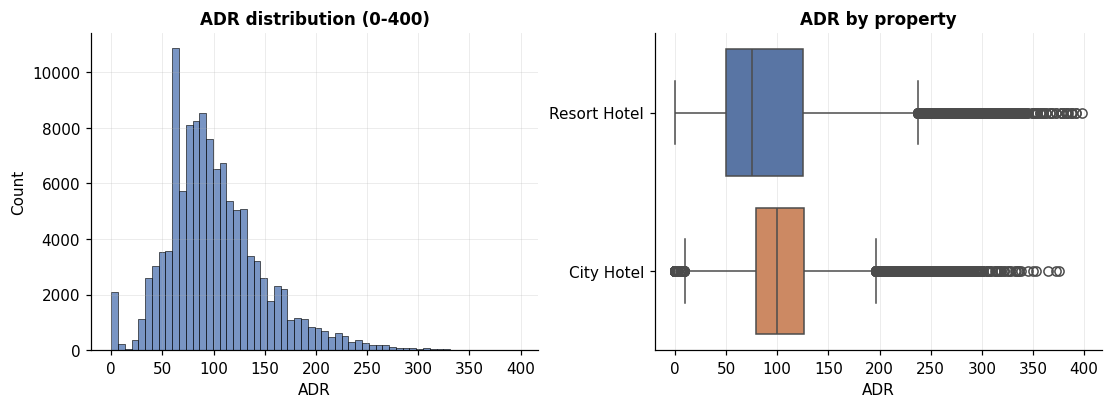

In [3]:
print(f"adr <= 0   : {(raw['adr'] <= 0).sum():,}")
print(f"adr > 1000 : {(raw['adr'] > 1000).sum():,}   (max {raw['adr'].max():,.0f})")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
sns.histplot(raw.loc[raw["adr"].between(0, 400), "adr"], bins=60, ax=axes[0], color="#4c72b0")
axes[0].set(title="ADR distribution (0-400)", xlabel="ADR")
sns.boxplot(data=raw[raw["adr"].between(0, 400)], x="adr", y="hotel", ax=axes[1],
            hue="hotel", legend=False, palette=["#4c72b0", "#dd8452"])
axes[1].set(title="ADR by property", xlabel="ADR", ylabel="")
save_fig("01_adr_distribution")
plt.show()

## 3. Cancellations

37% of all bookings are cancelled, which is far too large to ignore when valuing revenue.
The pattern that matters most for pricing is the **lead-time gradient**: bookings made
far in advance are roughly six times more likely to cancel than last-minute ones. The
simulator uses exactly this relationship, so getting its direction right is essential.

In [4]:
print(f"overall cancellation rate: {raw['is_canceled'].mean():.3f}")
print(raw.groupby("hotel")["is_canceled"].mean().round(3).to_string())

lead_bucket = pd.cut(raw["lead_time"], [-1, 7, 30, 90, 180, 1000],
                     labels=["0-7d", "8-30d", "31-90d", "91-180d", "180d+"])
by_lead = raw.groupby(lead_bucket, observed=True)["is_canceled"].agg(["mean", "size"])
print()
print(by_lead.round(3).to_string())

overall cancellation rate: 0.370
hotel
City Hotel      0.417
Resort Hotel    0.278

            mean   size
lead_time              
0-7d       0.096  19746
8-30d      0.279  18960
31-90d     0.377  29553
91-180d    0.447  26439
180d+      0.570  24692


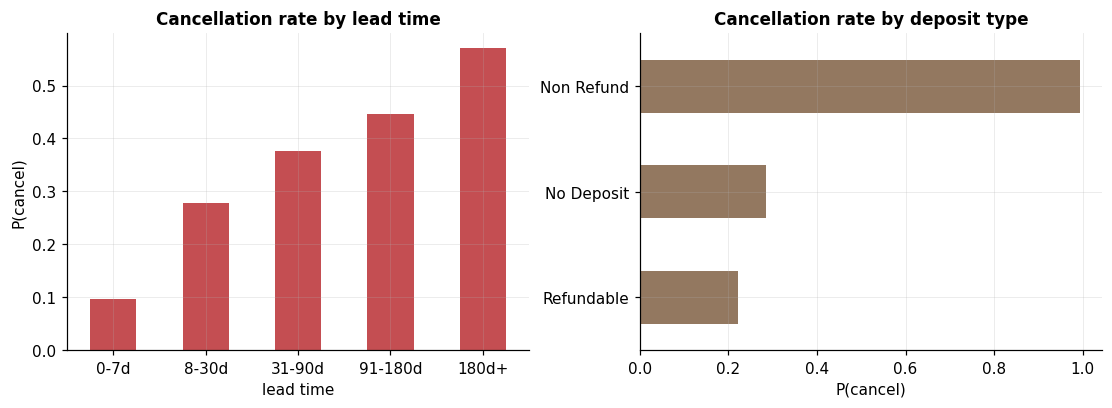

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
by_lead["mean"].plot(kind="bar", ax=axes[0], color="#c44e52", rot=0)
axes[0].set(title="Cancellation rate by lead time", ylabel="P(cancel)", xlabel="lead time")

by_deposit = raw.groupby("deposit_type")["is_canceled"].mean().sort_values()
by_deposit.plot(kind="barh", ax=axes[1], color="#937860")
axes[1].set(title="Cancellation rate by deposit type", xlabel="P(cancel)", ylabel="")
save_fig("01_cancellation_drivers")
plt.show()

## 4. Booking curve

Lead time converted to *weeks before arrival* gives the booking curve - the share of a
season's demand that arrives in each week of the selling window. It is heavily
back-loaded: 15% of all bookings are made in the final week. This shape drives the
scarcity trade-off the pricing agent has to solve.

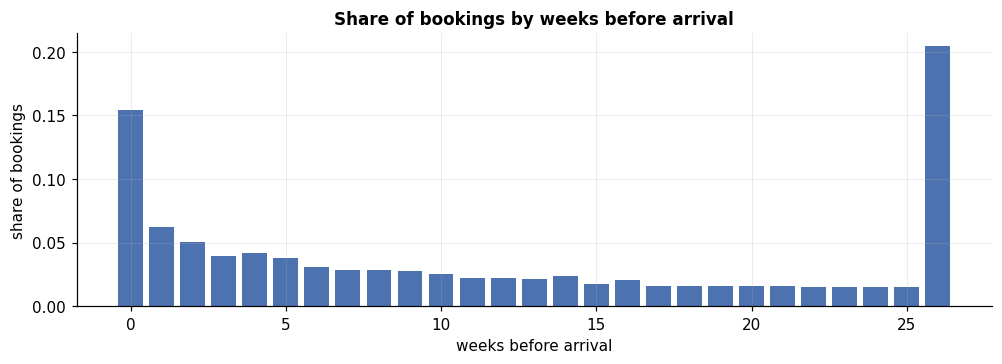

share booked within the final 12 weeks: 54.9%


In [6]:
weeks_before = (raw["lead_time"] // 7).clip(upper=26)
curve = weeks_before.value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(curve.index, curve.values, color="#4c72b0")
ax.set(title="Share of bookings by weeks before arrival", xlabel="weeks before arrival",
       ylabel="share of bookings")
save_fig("01_booking_curve")
plt.show()
print(f"share booked within the final 12 weeks: {curve.loc[:11].sum():.1%}")

## 5. Cleaning and export

Filters applied: `0 < adr < 1000`; drop `company`; fill `agent` and `children` with 0;
drop rows with no country; derive `total_nights` and `revenue`; drop zero-night stays.

In [7]:
clean = raw[raw["adr"].between(0, 1000, inclusive="neither")].copy()
clean = clean.drop(columns=["company"])
clean["agent"] = clean["agent"].fillna(0)
clean["children"] = clean["children"].fillna(0)
clean = clean.dropna(subset=["country"])

clean["total_nights"] = clean["stays_in_weekend_nights"] + clean["stays_in_week_nights"]
clean = clean[clean["total_nights"] > 0]
clean["revenue"] = clean["adr"] * clean["total_nights"]
clean["arrival_date_month"] = pd.Categorical(clean["arrival_date_month"],
                                             categories=MONTH_ORDER, ordered=True)

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
clean.to_csv(DATA_PROCESSED / "clean.csv", index=False)
print(f"cleaned: {clean.shape[0]:,} x {clean.shape[1]}  "
      f"({len(raw) - len(clean):,} rows removed)")
print(f"median stay {clean['total_nights'].median():.0f} nights, "
      f"median ADR {clean['adr'].median():.0f}")

cleaned: 116,962 x 33  (2,428 rows removed)
median stay 3 nights, median ADR 95
